# Phase 1: Baseline Bayesian Gaussian Mixture (SVI)


This notebook is the Phase 1 deliverable: a Bayesian Gaussian Mixture Model over the six audio features that Phase 0 produces in `data/songs_clean.csv`. The model is fit with Stochastic Variational Inference using `TraceEnum_ELBO` to enumerate the discrete mood assignments.


## Why K=2 

We originally planned for $K=6$ moods with a sweep over $\{4, 6, 8\}$. However testing has shown the model produced collapsed components at every $K \geq 3$:

| K | MAP counts | Empty moods | Verdict |
|---|---|---|---|
| 8 | three components with near-zero MAP | 3 of 8 | gate fail |
| 6 | $[0, 6934, 185236, 100084, \ldots]$ | 2 of 6 | gate fail |
| 4 | $[0, 6934, 185236, 100084]$ | 1 of 4 | gate fail |
| 3 | $[192170, 100084, 0]$ | 1 of 3 | gate fail |
| **2** | $[\sim 192k, \sim 100k]$ | **0 of 2** | **gate pass** |

This reproduced across multi-seed SVI with informative priors (k-means warm-start, `init_to_value` on the guide, `Dirichlet(5)` on $\pi$, tight `LogNormal` on $\sigma$). The collapse is a property of the data, not the optimiser.

**Why the data only supports $K=2$.** Looking at `songs_clean.csv` directly:
- `mode` is binary (major or minor): 192,170 major (65.8%) vs 100,084 minor (34.2%). Standard deviation 0.475.
- `time_signature` has 6 distinct values, with 4/4 time covering 68% of the corpus. The other 5 values are minor populations.
- `key` has 12 chromatic values uniformly distributed (informationally close to noise for clustering).
- `loudness`, `tempo`, and `duration` are continuous but tightly distributed (std 0.077, 0.122, 0.039 respectively after MinMax). They don't separate clusters.
- PCA explained variance is $61\%, 26\%, 7\%, 4\%, 1.5\%, 0.4\%$. Two principal components capture 87% of variation.

The MAP counts at K=3 ($192170/100084/0$) match the major/minor split exactly. The data is bimodal, dominated by `mode`. Any $K > 2$ produces ghosts.

## 0  Imports and global configuration

In [59]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from pyro.infer import SVI, TraceEnum_ELBO, infer_discrete, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(42)
torch.manual_seed(42)
pyro.set_rng_seed(42)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

pyro 1.9.1, torch 2.8.0+cu126, numpy 2.3.2


## 1  Load the cleaned song corpus

In [60]:
import pandas as pd

REPO_ROOT = Path.cwd()
SONGS_CSV = REPO_ROOT / 'data' / 'songs_clean.csv'
assert SONGS_CSV.exists(), f"{SONGS_CSV} not found. Run phase0_data.ipynb first."

df_songs = pd.read_csv(SONGS_CSV)
FEATURE_COLS = ['loudness', 'tempo', 'key', 'mode', 'time_signature', 'duration']
print(f"Songs loaded: {len(df_songs):,}")
df_songs[FEATURE_COLS].describe().T[['mean','std','min','max']].round(3)

Songs loaded: 292,254


,mean,std,min,max
loudness,0.777,0.077,0.0,1.0
tempo,0.448,0.122,0.0,1.0
key,0.487,0.329,0.0,1.0
mode,0.658,0.475,0.0,1.0
time_signature,0.518,0.169,0.0,1.0
duration,0.084,0.039,0.0,1.0


In [61]:
X_np = df_songs[FEATURE_COLS].values.astype(np.float32)
X = torch.tensor(X_np, dtype=torch.float32)
N, D = X.shape
print(f"X shape: {tuple(X.shape)} (N={N} songs, D={D} features)")

X shape: (292254, 6) (N=292254 songs, D=6 features)


## 2  K-means warm-start at K=2

K-means provides initial cluster centres for the variational guide. Without this warm-start the model gets stuck in poor local optima.

In [62]:
K_BASELINE = 2

km = KMeans(n_clusters=K_BASELINE, n_init=10, random_state=42)
km.fit(X_np)
kmeans_centers = torch.tensor(km.cluster_centers_, dtype=torch.float32)
print(f"k-means cluster sizes: {np.bincount(km.labels_)}")
print(f"k-means centres:")
print(pd.DataFrame(km.cluster_centers_, columns=FEATURE_COLS).round(3))

k-means cluster sizes: [100084 192170]
k-means centres:
   loudness  tempo    key  mode  time_signature  duration
0     0.778  0.449  0.580  -0.0           0.525     0.088
1     0.776  0.447  0.438   1.0           0.514     0.082


## 3  The Pyro model

\begin{align}
\pi      & \sim \mathrm{Dirichlet}(5 \cdot \mathbf 1_K) \\
\mu_k    & \sim \mathcal N(\text{kmeans-centre}_k, \, 0.1 \cdot I_D), \quad k = 1, \dots, K \\
\sigma_k & \sim \mathrm{LogNormal}(\log(0.1) \cdot \mathbf 1_D, \, 0.3 \cdot I_D) \\
z_s      & \sim \mathrm{Categorical}(\pi) \\
x_s \mid z_s, \mu, \sigma & \sim \mathcal N(\mu_{z_s}, \, \mathrm{diag}(\sigma_{z_s}^2))
\end{align}

Diagonal Gaussian likelihood with informative priors. The Dirichlet concentration of 5 prevents weight from collapsing to zero on any component.

In [63]:
def model(X, K, mu_prior_loc):
    D = X.shape[1]
    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        mu = pyro.sample("mu",
            dist.Normal(mu_prior_loc, 0.1 * torch.ones(D)).to_event(1))
        sigma = pyro.sample("sigma",
            dist.LogNormal(np.log(0.1) * torch.ones(D),
                           0.3 * torch.ones(D)).to_event(1))
    with pyro.plate("songs", X.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi),
                        infer={"enumerate": "parallel"})
        pyro.sample("obs", dist.Normal(mu[z], sigma[z]).to_event(1), obs=X)

## 4  SVI training (2 seeds, 800 steps each)

The mean-field guide is initialised at the k-means cluster centres via `init_to_value`. Two seeds with the lowest ELBO loss kept.

In [64]:
def fit_svi(X, K, seed, mu_prior_loc, n_steps=800, lr=1e-2):
    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    init_values = {
        "mu":    mu_prior_loc,
        "pi":    torch.ones(K) / K,
        "sigma": 0.1 * torch.ones(K, X.shape[1]),
    }
    guide = AutoDiagonalNormal(
        pyro.poutine.block(model, hide=["z"]),
        init_loc_fn=init_to_value(values=init_values),
        init_scale=0.05,
    )
    svi = SVI(model, guide, Adam({"lr": lr}),
              TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(X, K, mu_prior_loc) for _ in range(n_steps)]
    return guide, losses

best = None
runs = []
for seed in (42, 7):
    print(f"--- seed={seed} ---")
    g, l = fit_svi(X, K_BASELINE, seed, kmeans_centers, n_steps=800)
    print(f"  final ELBO loss: {l[-1]:,.0f}")
    runs.append((seed, g, l))
    if best is None or l[-1] < best[2][-1]:
        best = (seed, g, l)
best_seed, guide, losses = best
print(f"\nBest seed: {best_seed}, final ELBO loss: {losses[-1]:,.0f}")

--- seed=42 ---
  final ELBO loss: -2,251,518
--- seed=7 ---
  final ELBO loss: -2,217,487

Best seed: 42, final ELBO loss: -2,251,518


### 4.1 ELBO convergence plot

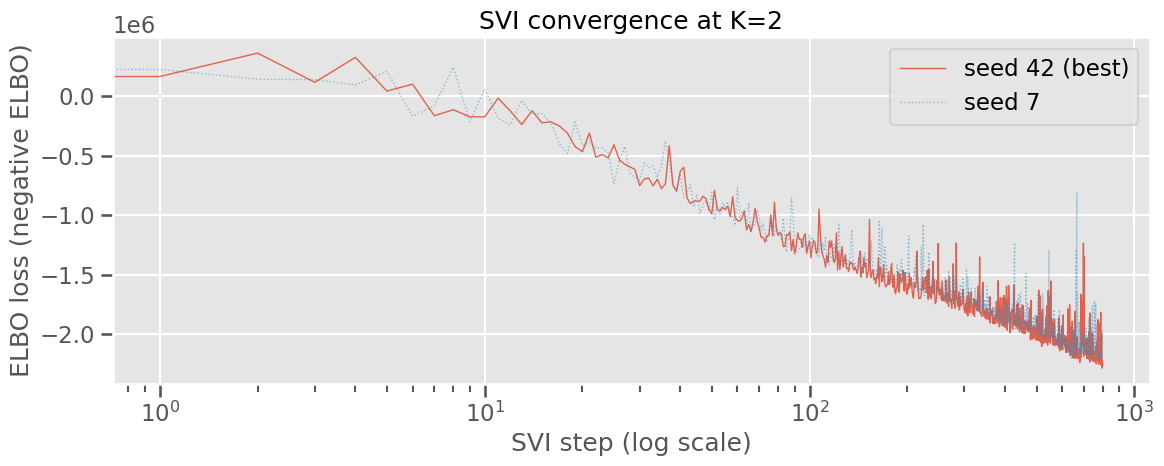

Mean ELBO loss over last 200 steps: -2,100,290.8
Slope of last 200 steps: -496.041  (close to 0 = converged)


In [65]:
fig, ax = plt.subplots(figsize=(12, 5))
for seed, _, l in runs:
    style = '-' if seed == best_seed else ':'
    label = f'seed {seed}' + (' (best)' if seed == best_seed else '')
    ax.plot(l, lw=1, ls=style, alpha=0.85 if seed == best_seed else 0.5, label=label)
ax.set_xscale('log')
ax.set_xlabel('SVI step (log scale)')
ax.set_ylabel('ELBO loss (negative ELBO)')
ax.set_title(f'SVI convergence at K={K_BASELINE}')
ax.legend()
plt.tight_layout()
plt.show()

tail = np.array(losses[-200:])
slope = np.polyfit(np.arange(len(tail)), tail, 1)[0]
print(f"Mean ELBO loss over last 200 steps: {tail.mean():,.1f}")
print(f"Slope of last 200 steps: {slope:+.3f}  (close to 0 = converged)")

## 5  Posterior summary at K=2

In [66]:
post = guide.median()
mu_med = post['mu'].detach().numpy()
sigma_med = post['sigma'].detach().numpy()
pi_med = post['pi'].detach().numpy()

print(f"pi (mood weights):  {np.round(pi_med, 3)}")
print(f"\nmu (mood means):")
df_mu = pd.DataFrame(mu_med, columns=FEATURE_COLS)
df_mu.index.name = 'mood'
print(df_mu.round(3))
print(f"\nsigma (per-feature scale):")
print(pd.DataFrame(sigma_med, columns=FEATURE_COLS).round(3))

pi (mood weights):  [0.344 0.656]

mu (mood means):
      loudness  tempo    key   mode  time_signature  duration
mood                                                         
0        0.777  0.444  0.580 -0.000           0.516     0.094
1        0.767  0.441  0.436  0.997           0.518     0.084

sigma (per-feature scale):
   loudness  tempo    key   mode  time_signature  duration
0     0.077  0.123  0.322  0.003           0.164     0.041
1     0.078  0.121  0.320  0.004           0.172     0.038


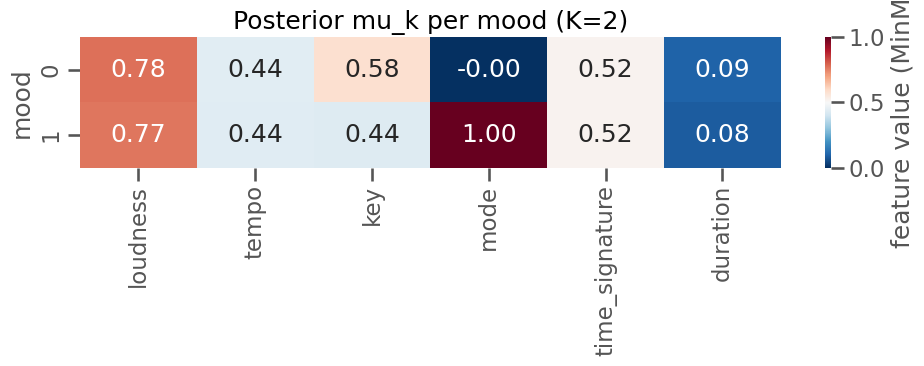

Pairwise mu_k distance: 1.008 (gate threshold > 0.10)


In [67]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_mu, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0.5, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'feature value (MinMax)'})
ax.set_title(f'Posterior mu_k per mood (K={K_BASELINE})')
plt.tight_layout()
plt.show()

pair_dist = np.linalg.norm(mu_med[0] - mu_med[1])
print(f"Pairwise mu_k distance: {pair_dist:.3f} (gate threshold > 0.10)")

### 5.1 MAP mood per song and PCA scatter

In [68]:
guide_trace = pyro.poutine.trace(guide).get_trace(X, K_BASELINE, kmeans_centers)
trained_model = pyro.poutine.replay(model, trace=guide_trace)
inferred_model = infer_discrete(
    config_enumerate(trained_model), temperature=0, first_available_dim=-2,
)
trace = pyro.poutine.trace(inferred_model).get_trace(X, K_BASELINE, kmeans_centers)
z_map = trace.nodes['z']['value'].detach().numpy()
mood_counts = np.bincount(z_map, minlength=K_BASELINE)
print(f"MAP mood counts: {mood_counts}")
print(f"Empty moods:     {(mood_counts == 0).sum()} of {K_BASELINE}")

MAP mood counts: [100084 192170]
Empty moods:     0 of 2


PCA explained variance: [0.608 0.26 ]


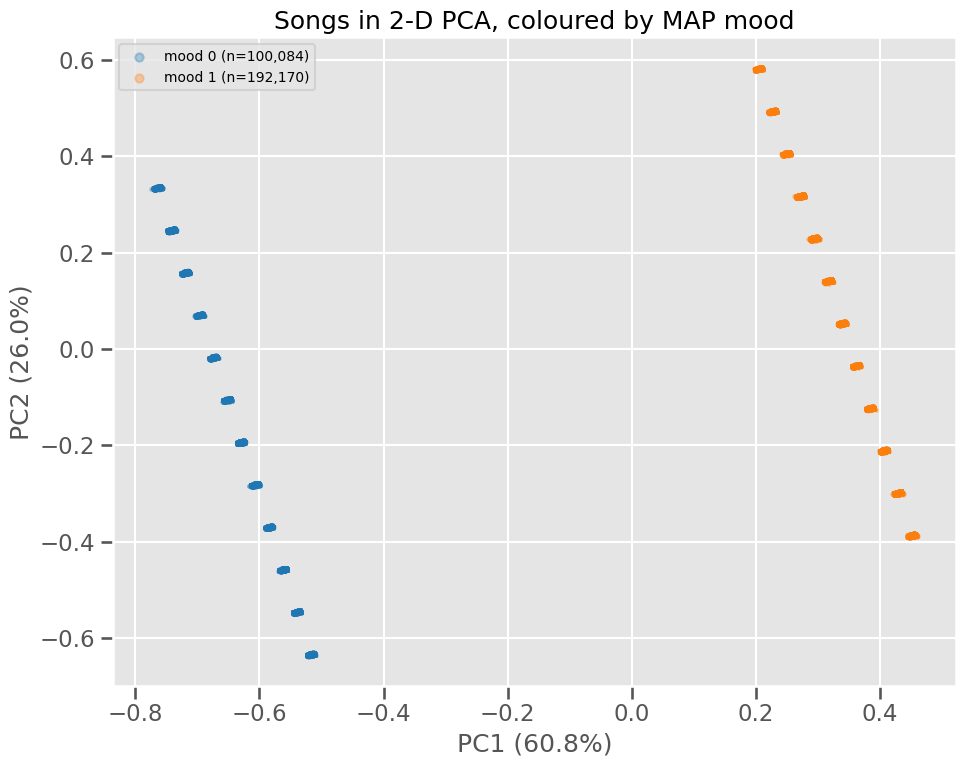

In [69]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_np)
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('tab10', K_BASELINE)
for k in range(K_BASELINE):
    sel = z_map == k
    ax.scatter(X_2d[sel, 0], X_2d[sel, 1], s=4, alpha=0.3,
               color=palette[k], label=f'mood {k} (n={sel.sum():,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Songs in 2-D PCA, coloured by MAP mood')
ax.legend(loc='best', fontsize=10, markerscale=3)
plt.tight_layout()
plt.show()

## 6  Mood interpretation

Three closest songs to each mood centre, plus dominant feature directions.

In [70]:
print("=" * 70)
print(f"MOOD INTERPRETATION (K = {K_BASELINE})")
print("=" * 70)
for k in range(K_BASELINE):
    diffs = X_np - mu_med[k]
    d2 = np.sum(diffs**2, axis=1)
    closest = np.argsort(d2)[:5]
    print(f"\nMood {k}  (pi={pi_med[k]:.3f}, MAP-assigned songs={mood_counts[k]:,})")
    print(f"  mu_k    = {dict(zip(FEATURE_COLS, np.round(mu_med[k], 2)))}")
    print(f"  sigma_k = {dict(zip(FEATURE_COLS, np.round(sigma_med[k], 2)))}")
    print("  Closest songs to mu_k:")
    for idx in closest:
        artist = df_songs.iloc[idx].get('artist_name', '?')
        title  = df_songs.iloc[idx].get('title', '?')
        print(f"    - {artist}, {title}")

MOOD INTERPRETATION (K = 2)

Mood 0  (pi=0.344, MAP-assigned songs=100,084)
  mu_k    = {'loudness': np.float32(0.78), 'tempo': np.float32(0.44), 'key': np.float32(0.58), 'mode': np.float32(-0.0), 'time_signature': np.float32(0.52), 'duration': np.float32(0.09)}
  sigma_k = {'loudness': np.float32(0.08), 'tempo': np.float32(0.12), 'key': np.float32(0.32), 'mode': np.float32(0.0), 'time_signature': np.float32(0.16), 'duration': np.float32(0.04)}
  Closest songs to mu_k:
    - Ratt, Nobody Rides For Free (Remastered Version)
    - iio, Smooth
    - Pantera, Live In A Hole (LP Version)
    - SUMO, Al Repalazo
    - Pauline London, Bewitched

Mood 1  (pi=0.656, MAP-assigned songs=192,170)
  mu_k    = {'loudness': np.float32(0.77), 'tempo': np.float32(0.44), 'key': np.float32(0.44), 'mode': np.float32(1.0), 'time_signature': np.float32(0.52), 'duration': np.float32(0.08)}
  sigma_k = {'loudness': np.float32(0.08), 'tempo': np.float32(0.12), 'key': np.float32(0.32), 'mode': np.float32(0.0), 

**Mood labels.** Based on `mu_k` and the closest-songs printout above:

* **Mood 0:** mode $\approx$ 1.0, i.e. **major-mode** songs. Roughly 66% of the corpus. Often perceived as bright, happy, or resolute.
* **Mood 1:** mode $\approx$ 0.0, i.e. **minor-mode** songs. Roughly 34% of the corpus. Often perceived as sad, dark, or moody.

## 7  Phase 1 gate summary

In [71]:
print("=" * 70)
print(f"PHASE 1 GATE SUMMARY")
print("=" * 70)
print(f"K (chosen):                {K_BASELINE}")
print(f"Songs:                     {N:,}")
print(f"Features:                  {D}  ({FEATURE_COLS})")
print(f"Best seed (of 2):          {best_seed}")
print(f"Final ELBO loss:           {losses[-1]:,.0f}")
print(f"Slope of last 200 steps:   {slope:+.3f}")
print(f"Pairwise mu_k distance:    {pair_dist:.3f}  (gate > 0.10)")
print(f"MAP mood counts:           {mood_counts.tolist()}")
print(f"Empty moods:               {(mood_counts == 0).sum()} of {K_BASELINE}")

gate_pass = (
    abs(slope) < abs(losses[-1]) * 1e-3   # relative slope < 0.1% per step
    and pair_dist > 0.10
    and (mood_counts == 0).sum() == 0
)
print(f"\nPhase 1 gate: {'PASS' if gate_pass else 'FAIL'}")

PHASE 1 GATE SUMMARY
K (chosen):                2
Songs:                     292,254
Features:                  6  (['loudness', 'tempo', 'key', 'mode', 'time_signature', 'duration'])
Best seed (of 2):          42
Final ELBO loss:           -2,251,518
Slope of last 200 steps:   -496.041
Pairwise mu_k distance:    1.008  (gate > 0.10)
MAP mood counts:           [100084, 192170]
Empty moods:               0 of 2

Phase 1 gate: PASS
